In [10]:
from typing import List

In [ ]:
"""
455 Assign Cookies
有一群孩子和一堆饼干，每个孩子有一个饥饿度，每个饼干都有一个饱腹度。每个孩子只能
吃一个饼干，且只有饼干的饱腹度不小于孩子的饥饿度时，这个孩子才能吃饱。求解最多有多少
孩子可以吃饱。
"""


# 输入两个数组，分别代表孩子的饥饿度和饼干的饱腹度。输出可以吃饱的孩子的最大数量

def findContentChildren(children: list[int], cookies: list[int]) -> int:
    """
    children: list 每个位置代表所有孩子饿的程度
    cookies: list 每个位置代表cookie的能量
    return 可以吃饱的孩子的最大数量
    """
    # 先排序
    children.sort()
    cookies.sort()

    # 初始化两个数组的指针位置
    children_i, cookies_i = 0, 0

    # 得到两个数组的长度
    children_n, cookies_n = len(children), len(cookies)

    # 循环
    while children_i < children_n and cookies_i < cookies_n:
        # 如果最小的cookie能让最不饿的孩子饱腹
        if cookies[cookies_i] >= children[children_i]:
            # 把最小的cookie分给最不饿的孩子，这个孩子就饱了
            # 我们再考虑下一个孩子
            children_i += 1
        # 如果最小的cookie不能让孩子饱腹，我们需要考虑更大的cookie
        cookies_i += 1
    
    # 返回能让孩子饱腹的个数
    print(children_i)
    return children_i


findContentChildren([1,1,1,1], [1,1,1,1])
findContentChildren([1,2,3], [4,5])
findContentChildren([4,5,6], [1,2,3])
print("")


4
2
0



In [ ]:
"""
135 Candy
一群孩子站成一排，每一个孩子有自己的评分。现在需要给这些孩子发糖果，规则是如果一
个孩子的评分比自己身旁的一个孩子要高，那么这个孩子就必须得到比身旁孩子更多的糖果。所
有孩子至少要有一个糖果。求解最少需要多少个糖果。
"""

# 输入是一个数组，表示孩子的评分。输出是最少糖果的数量。


# -> 分数最低的孩子只有一个糖？然后递归
# 思路行不通


# 如果是一个简单的求和序列，符合结果吗？
def candy_by_rank(children: list) -> int:
    total_sum = 0
    current_num = 1
    children.sort()
    for i in range(0, len(children)):
        total_sum += current_num
        if i == len(children)-1:
            break
        else:
            if children[i] < children[i+1]:
                current_num +=1
    return total_sum

test_list_1 = [1, 0, 2]
test_list_2 = [1, 2, 2]


# 首先，题目要求孩子左右相邻不能排序
# 其次test_list_1显然可以[2, 1, 1]这样分配，明显不用candy_by_rank
print(candy_by_rank(test_list_1))
print(candy_by_rank(test_list_2))


# 转变思路，如果一开始给所有人都分一个糖
# 向左遍历，如果有更高的则加一；向右遍历，如果有更高的则加一
def candy(ratings_list: list[int]) -> int:
    n = len(ratings_list)
    candies = [1] * n
    for i in range(1, n):
        if ratings_list[i] > ratings_list[i-1]:
            candies[i] = candies[i-1] + 1
    for i in range(n-1, 0, -1):
        if ratings_list[i] < ratings_list[i-1]:
            candies[i] = max(candies[i-1], candies[i]+1)
    return sum(candies)

print(candy(test_list_1))
print(candy(test_list_2))




6
5
6
4


In [ ]:
"""
435 Non-overlapping Intervals
给定多个区间，计算让这些区间互补重叠所需要移除区间的最少个数。
起止相连不算重叠。
"""

# 输入是一个数组，包含多个长度固定为2的子数组，表示每个区间的开始和结尾。
# 输出一个整数，表示需要移除的区间数量。

def eraseOverlapIntervals(intervals: List[List[int]]) -> int:
    # 首先根据关键字（每个小区间的结尾）对所有的小区间进行排序
    intervals.sort(key=lambda x: x[1])
    # 初始化要被移除的区间数量，第一个小区间的结尾
    removed, prev_end = 0, intervals[0][1]
    # 遍历所有区间，优先保留结尾小且不相交的区间
    for i in range(1, len(intervals)): # 从第二个区间开始
        # 如果前一个区间的结尾大于当前区间的开头->即有重叠
        if prev_end > intervals[i][0]:
            # 则移除这个区间
            removed +=1
        else:
            # 否则保留这个区间，然后将这个区间的结尾作为prev_end
            prev_end = intervals[i][1]
    return removed

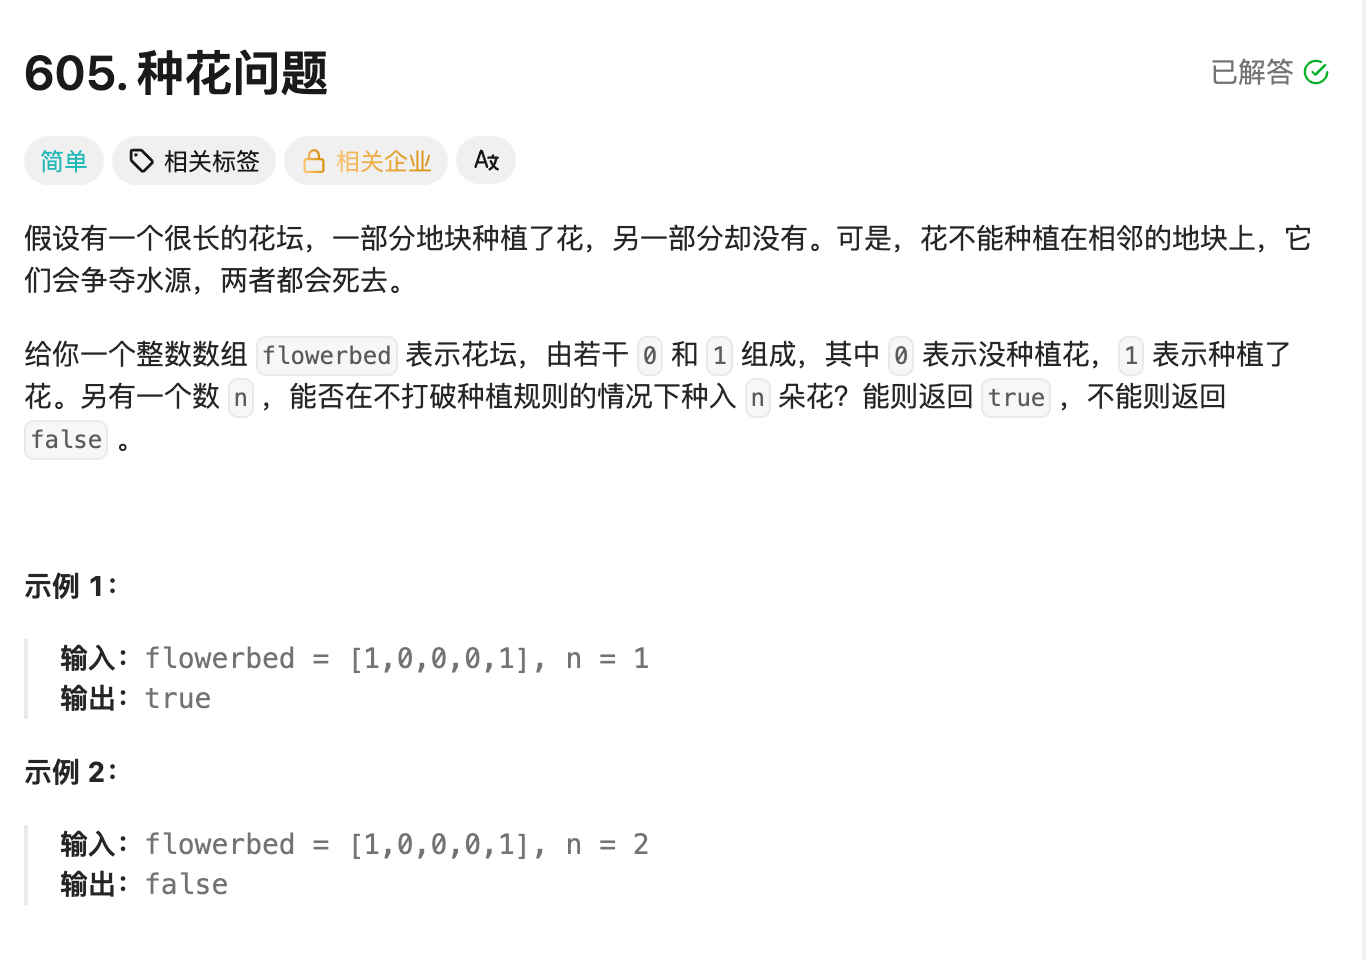

In [ ]:
"""
我的解答
"""

class Solution:
    def canPlaceFlowers(self, flowerbed: List[int], n: int) -> bool:
        list_n = len(flowerbed)
        plant_num = 0
        # 处理特殊情况-长度为1时，0可以种一个，1不能种
        if len(flowerbed) == 1:
            if flowerbed[0] == 0:
                plant_num = 1
        # 长度为2时，有一个1就不能种
        elif len(flowerbed) == 2:
            if flowerbed[0] + flowerbed[1] == 0:
                plant_num = 1
        # 长度大于等于3时，可以用一般逻辑判断
        else:
            # 处理特殊情况，开头只用判断第一个和第二个
            if flowerbed[0] + flowerbed[1] == 0:
                plant_num += 1
                flowerbed[0] = 1
            # 相邻三个必须都为0，则中间的可以种
            for i in range(1, len(flowerbed)-1):
                if flowerbed[i-1] + flowerbed[i] + flowerbed[i+1] == 0:
                    plant_num += 1
                    flowerbed[i] = 1
                i += 1
            # 处理特殊情况，结尾只用判断倒数第一和倒数第二
            if flowerbed[-2] + flowerbed[-1] == 0:
                plant_num += 1
                flowerbed[-1] = 1

        if plant_num >= n:
            return True
        else:
            return False

        

In [ ]:
"""
官方解答
"""

class Solution:
    def canPlaceFlowers(self, flowerbed: List[int], n: int) -> bool:
        # 初始化能种花的数量，列表的长度，以及上一个值为1的位置（初始化为负数，并不是列表的最后一个元素）
        count, m, prev = 0, len(flowerbed), -1
        # 遍历列表所有的值
        for i in range(m):
            # 找到种花的位置
            if flowerbed[i] == 1:
                # 如果是第一个种花的位置,则第一个位置的左侧全都可以种花
                if prev < 0:
                    count += i // 2
                # 如果是中间种花的位置，则需要考虑两个花之间能种多少花
                else:
                    count += (i - prev - 2) // 2

                # 进一步的优化：如果count已经大于n了就直接返回
                if count > n:
                    return True
                # 更新prev的值
                prev = i
        # 现在所有是1的值都已经遍历完了，而是0的值则不会进行任何操作

        # 如果整个序列里全都是0
        if prev == -1:
            count = (m + 1)// 2
        # 否则，需要考虑最后一个1值位置的右边有多少个0
        else:
            count += (m - prev -1) // 2
        
        # 返回答案
        return count >= n

                

In [ ]:
"""
最简单解答
"""
class Solution:
    def canPlaceFlowers(self, flowerbed: List[int], n: int) -> bool:
        # 在数组的前后各补一个0
        flowerbed = [0] + flowerbed + [0]
        # 从下标为1开始到倒数第二个
        for i in range(1, len(flowerbed)-1):
            # 判断条件
            if flowerbed[i-1] == 0 and flowerbed[i] == 0 and flowerbed[i+1] == 0:
                flowerbed[i] = 1
                # 此处可以种花，则距离目标少1
                n -= 1
        return n <= 0

"""
如果不想创建or修改原数组
"""
class Solution:
    def canPlaceFlowers(self, flowerbed: List[int], n: int) -> bool:
        i, m = 0, len(flowerbed)
        while i < m:
            # or之前的如果判断为真，则不会判断后面的表达式，这样解决了数组最前和最后下标溢出的问题
            # 剩下的则和普通的判断标准一致
            if (i==0 or flowerbed[i-1]==0) and flowerbed[i]==0 and (i==m-1 or flowerbed[i+1]==0):
                n -= 1
                # 如果这个位置可以种花，那么下一个位置一定不能种花，直接判断后一个位置
                i += 2
            else:
                # 如果这个位置不能种花，则考虑下一个位置能不能种花
                i += 1
        return n <= 0